# QualCheck – Training Pipeline (SciEntsBank Edition)

**Camarines Sur Polytechnic Colleges – College of Computer Studies**

This notebook adapts QualCheck to the **SciEntsBank** dataset ([Dzikovska et al., SemEval-2013](https://aclanthology.org/S13-2045)), loaded directly from HuggingFace.

### SciEntsBank → QualCheck mapping
| SciEntsBank column | Role in QualCheck |
|---|---|
| `question` | `question` |
| `student_answer` | `response` |
| `reference_answer` | `rubric_descriptor` (model answer = rubric) |
| 5-way label | mapped to 3-class QualCheck label (see Config) |

### Label mapping (5-way → 3-way QualCheck)
| SciEntsBank label | QualCheck label |
|---|---|
| `correct` | Fully Relevant |
| `contradictory`, `partially_correct_incomplete` | Partially Relevant |
| `irrelevant`, `non_domain` | Irrelevant |

### Test splits evaluated
SciEntsBank ships with **three** held-out test sets:
- `test_ua` – Unseen Answers (540 rows)
- `test_uq` – Unseen Questions (733 rows)
- `test_ud` – Unseen Domains (4,562 rows)

The notebook evaluates QualCheck on all three and reports results per split.

In [1]:
!pip install transformers torch scikit-learn pandas numpy nltk spacy scipy statsmodels matplotlib seaborn tqdm datasets safetensors -q
!python -m spacy download en_core_web_sm -q

import nltk
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
print('✓ Packages ready')

✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
✓ Packages ready


In [2]:
import os, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from tqdm.auto import tqdm
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import (BertTokenizer, BertModel,
                          get_linear_schedule_with_warmup)
from torch.optim import AdamW
from safetensors.torch import save_file as st_save_file, load_file as st_load_file
import json as _json

from datasets import load_dataset, Dataset as HFDataset, DatasetDict  # HuggingFace datasets (aliased: torch.utils.data.Dataset is already imported above)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score,
                              precision_score, recall_score)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity as tfidf_cos

from scipy.stats  import pearsonr, f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd

import nltk
from nltk.corpus import stopwords
from nltk.stem   import WordNetLemmatizer

print('✓ Imports complete')


✓ Imports complete


## Configuration

In [3]:
import os
from pathlib import Path

_EXPECTED_CSVS = {
    "scientsbank_train.csv", "scientsbank_test_ua.csv",
    "scientsbank_test_uq.csv", "scientsbank_test_ud.csv",
}

def _find_data_dir(folder_name="short_answer", search_up=5, search_down_depth=4):
    """
    Jupyter's kernel working directory is NOT always the folder the
    .ipynb file lives in, so a hardcoded relative path can fail even
    when the data genuinely exists on disk. This tries two strategies:

      1. Upward search — checks cwd and up to `search_up` parent
         directories for '<dataset|datasets>/<folder_name>' as a direct
         child (both singular and plural spellings, since this varies
         across projects).
      2. Downward search — walks cwd's subdirectories up to
         `search_down_depth` levels deep, looking for any directory
         literally named `folder_name` that actually contains the
         4 expected SciEntsBank CSVs (handles cases where the data
         folder isn't a direct child of cwd, or isn't under a
         dataset(s) parent at all).

    If neither finds it, raises a FileNotFoundError that prints the
    actual contents of cwd, so the real folder structure is visible
    immediately instead of requiring another round of guessing.
    """
    cwd = Path.cwd()

    # Strategy 1: upward search for <dataset|datasets>/<folder_name>
    up_candidates = [cwd] + list(cwd.parents)[:search_up]
    for base in up_candidates:
        for parent_name in ("dataset", "datasets"):
            candidate = base / parent_name / folder_name
            if candidate.is_dir():
                return str(candidate)

    # Strategy 2: downward search for folder_name containing the CSVs
    for root, dirs, files in os.walk(cwd):
        rel = Path(root).relative_to(cwd)
        depth = len(rel.parts)
        if depth > search_down_depth:
            dirs[:] = []   # stop descending past the depth limit
            continue
        if Path(root).name == folder_name and _EXPECTED_CSVS & set(files):
            return root

    # Nothing found — show what's actually in cwd so this is fixable
    # in one shot instead of another back-and-forth
    tree_preview = []
    for item in sorted(cwd.iterdir()):
        marker = "/" if item.is_dir() else ""
        tree_preview.append(f"  {item.name}{marker}")

    raise FileNotFoundError(
        f"Could not locate a '{folder_name}' folder containing the SciEntsBank "
        "CSVs (scientsbank_train.csv, scientsbank_test_ua.csv, etc.).\n\n"
        f"Current working directory: {cwd}\n"
        f"Contents of that directory:\n" + "\n".join(tree_preview) +
        "\n\nFix: either place your CSVs in a folder literally named "
        f"'{folder_name}' somewhere under this working directory, or set "
        "cfg.DATA_DIR to the correct absolute path manually before running Step 1."
    )


class Config:
    # ── Dataset ───────────────────────────────────────────────────
    # Local SciEntsBank CSVs (already exported from nkazi/SciEntsBank).
    # DATA_DIR is auto-resolved by _find_data_dir() above — see that
    # function's docstring if you hit a FileNotFoundError here.
    DATA_DIR    = _find_data_dir()
    TRAIN_CSV   = f"{DATA_DIR}/scientsbank_train.csv"
    TEST_UA_CSV = f"{DATA_DIR}/scientsbank_test_ua.csv"
    TEST_UQ_CSV = f"{DATA_DIR}/scientsbank_test_uq.csv"
    TEST_UD_CSV = f"{DATA_DIR}/scientsbank_test_ud.csv"

    # ── SciEntsBank 5-way → 3-way QualCheck mapping ───────────────
    # SciEntsBank integer labels (from HF):
    #   0 = correct
    #   1 = contradictory
    #   2 = partially_correct_incomplete
    #   3 = irrelevant
    #   4 = non_domain
    SEB_TO_QC = {
        0: "Fully Relevant",       # correct
        1: "Partially Relevant",   # contradictory
        2: "Partially Relevant",   # partially_correct_incomplete
        3: "Irrelevant",           # irrelevant
        4: "Irrelevant",           # non_domain
    }

    # ── QualCheck labels ──────────────────────────────────────────
    LABEL2ID   = {"Fully Relevant": 2, "Partially Relevant": 1, "Irrelevant": 0}
    ID2LABEL   = {2: "Fully Relevant",  1: "Partially Relevant", 0: "Irrelevant"}
    NUM_LABELS = 3

    # ── Rubric construction ─────────────────────────────────────────
    # SciEntsBank has no criterion-level rubric — only a single
    # reference_answer per question. Because the admin panel UI
    # collects THREE separate criterion boxes for Short Answer
    # (Accuracy of Answer / Key Concept / Clarity), training data must
    # be shaped the same way so the model sees the same rubric
    # structure at train time and inference time. See the
    # 'Multi-Criteria Rubric Synthesis' cell below (Step 1.5) for the
    # template pools and build_multi_criteria_rubric() used instead
    # of a flat RUBRIC_PREFIX.

    # ── BERT ─────────────────────────────────────────────────────
    BERT_MODEL = "bert-base-uncased"
    MAX_LEN    = 128    # short answers → 128 is sufficient

    # ── Training ─────────────────────────────────────────────────
    # LR and MAX_EPOCHS are fixed by Chapter 3 Phase 2 ("AdamW optimizer, a
    # learning rate of 2e-5, and a maximum of 5 training epochs") and are not
    # tuned here. BATCH_SIZE and DROPOUT below were adjusted to counter the
    # overfitting visible in the original run (train_acc 0.43→0.82 over 5
    # epochs while val_loss bottomed at epoch 3 then rose) — neither value is
    # specified in the thesis text, so both are safe to tune.
    BATCH_SIZE   = 16   # was 32 — more gradient steps per epoch on ~4.2k rows
    LR           = 2e-5
    MAX_EPOCHS   = 5
    PATIENCE     = 3
    WARMUP_RATIO = 0.1
    DROPOUT      = 0.4  # was 0.3 — stronger regularization on the classifier head

    # ── Split (train → 85% train / 15% val; all 3 test sets kept) ─
    VAL_RATIO  = 0.15
    SEED       = 42

    # ── Threshold calibration ────────────────────────────────────
    THRESH_STEP = 0.01

    # ── Output ───────────────────────────────────────────────────
    OUTPUT_DIR         = "qualcheck_short_answers"
    BEST_CKPT           = "qualcheck_short_answers/best_model.safetensors"
    FINAL_MODEL_WEIGHTS = "qualcheck_short_answers/qualcheck_short_answers_final.safetensors"
    FINAL_MODEL_META    = "qualcheck_short_answers/qualcheck_short_answers_final_meta.json"

    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

cfg = Config()
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)

random.seed(cfg.SEED); np.random.seed(cfg.SEED); torch.manual_seed(cfg.SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(cfg.SEED)

print(f"Device        : {cfg.DEVICE}")
print(f"CUDA          : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU           : {torch.cuda.get_device_name(0)}")
print(f"Data directory : {cfg.DATA_DIR}")


Device        : cuda
CUDA          : True


GPU           : NVIDIA RTX A5000
Data directory : /home/marcdextersael/THESIS_2_BOSS_BATTLE/datasets/short_answer


## Phase 1 – Data Loading & Adaptation

### Step 1 – Load from Local CSVs (datasets/short_answers/)

In [4]:
print(f"Loading SciEntsBank from local CSVs in {cfg.DATA_DIR} …")

# Pre-flight check — fail with a clear message instead of a raw pandas traceback
_csv_paths = {
    "train"   : cfg.TRAIN_CSV,
    "test_ua" : cfg.TEST_UA_CSV,
    "test_uq" : cfg.TEST_UQ_CSV,
    "test_ud" : cfg.TEST_UD_CSV,
}
_missing = {name: p for name, p in _csv_paths.items() if not Path(p).is_file()}
if _missing:
    print("Files found in", cfg.DATA_DIR, ":", os.listdir(cfg.DATA_DIR))
    raise FileNotFoundError(
        "Missing CSV file(s):\n  " +
        "\n  ".join(f"{name} -> {p}" for name, p in _missing.items()) +
        "\n\nCheck the exact filenames above against what's actually in "
        f"{cfg.DATA_DIR} (case-sensitive, must end in .csv)."
    )

raw = DatasetDict({
    "train"   : HFDataset.from_pandas(pd.read_csv(cfg.TRAIN_CSV)),
    "test_ua" : HFDataset.from_pandas(pd.read_csv(cfg.TEST_UA_CSV)),
    "test_uq" : HFDataset.from_pandas(pd.read_csv(cfg.TEST_UQ_CSV)),
    "test_ud" : HFDataset.from_pandas(pd.read_csv(cfg.TEST_UD_CSV)),
})

print("\nAvailable splits:")
for name, ds in raw.items():
    print(f"  {name:<12}  {len(ds):>6,} rows  |  columns: {ds.column_names}")

# Preview one row — verify these columns include question / reference_answer /
# student_answer / label before continuing to Step 2
sample = raw["train"][0]
print("\nSample train row:")
for k, v in sample.items():
    print(f"  {k:<20}: {str(v)[:80]}")


Loading SciEntsBank from local CSVs in /home/marcdextersael/THESIS_2_BOSS_BATTLE/datasets/short_answer …

Available splits:
  train          4,969 rows  |  columns: ['id', 'question', 'reference_answer', 'student_answer', 'label']
  test_ua          540 rows  |  columns: ['id', 'question', 'reference_answer', 'student_answer', 'label']
  test_uq          733 rows  |  columns: ['id', 'question', 'reference_answer', 'student_answer', 'label']
  test_ud        4,562 rows  |  columns: ['id', 'question', 'reference_answer', 'student_answer', 'label']

Sample train row:
  id                  : EM.45b.110.1
  question            : You used several methods to separate and identify the substances in mock rocks. 
  reference_answer    : The water was evaporated, leaving the salt.
  student_answer      : By letting it sit in a dish for a day.
  label               : 3


### Step 1.5 – Multi-Criteria Rubric Synthesis

SciEntsBank only provides a single `reference_answer` per question — there is no criterion-level rubric in the source dataset. The admin panel UI, however, collects **three** separate rubric boxes for the Short Answer output type (*Accuracy of Answer*, *Key Concept*, *Clarity*), mirroring the multi-criterion structure used for Code Report. To keep train-time rubric text shaped the same way it will appear at inference time, each of the three criteria is synthesized here — *Accuracy of Answer* is grounded in the question's `reference_answer`, while *Key Concept* and *Clarity* are drawn from small non-adjacent-repeat phrasing pools (same technique used for the Code Report synthetic descriptors). The question itself is deliberately **not** reinserted into Key Concept — it's already part of `P` on its own via `[CLS] prompt [SEP] rubric [SEP]`, so repeating it in the rubric would just echo existing content rather than add a real criterion. The three criterion strings are then concatenated into a single `rubric_descriptor`, matching Chapter 3 Phase 2's input format, which only ever expects **one** rubric string per sample.

In [5]:
# ── Multi-criteria rubric phrasing pools ─────────────────────────
# 'Accuracy of Answer' is grounded in the question's reference_answer
# (varied by template so the model isn't just memorizing one fixed
# prefix). 'Key Concept' and 'Clarity' have no source data in
# SciEntsBank, so they draw from small template pools instead —
# same non-adjacent-repeat technique used for the Code Report
# synthetic descriptors.

ACCURACY_TEMPLATES = [
    "Accuracy of Answer: the response should correctly state that {ref}",
    "Accuracy of Answer: a correct answer must include the fact that {ref}",
    "Accuracy of Answer: to be accurate, the response needs to explain that {ref}",
    "Accuracy of Answer: does the response affirm that {ref}?",
    "Accuracy of Answer: the answer is correct only if it states that {ref}",
]

# NOTE: Key Concept intentionally does NOT re-insert the question text.
# The question is already fed separately as part of P in Phase 2
# ([CLS] prompt [SEP] rubric [SEP]) — repeating it here would just echo
# content the model already sees, not add a real per-item criterion.
KEY_CONCEPT_TEMPLATES = [
    "Key Concept: the response should demonstrate understanding of the core idea being tested",
    "Key Concept: does the answer engage with the central concept the question is testing?",
    "Key Concept: the response must show grasp of the main idea being asked about",
    "Key Concept: has the student identified the key concept underlying the question?",
]

CLARITY_TEMPLATES = [
    "Clarity: the answer should be expressed in clear, well-formed sentences",
    "Clarity: is the response easy to follow and free of ambiguity?",
    "Clarity: the explanation should be organized and unambiguous",
    "Clarity: express the answer clearly, without vague or confusing wording",
    "Clarity: the response should communicate its point without unnecessary confusion",
]


def _non_adjacent_pick(pool, rng, last_idx):
    """Pick a random index from pool that differs from the previous pick."""
    idx = rng.randrange(len(pool))
    if len(pool) > 1:
        while idx == last_idx:
            idx = rng.randrange(len(pool))
    return idx, pool[idx]


def build_multi_criteria_rubric(reference_answer, rng, last_idxs):
    """
    Synthesizes a 3-criteria rubric string (Accuracy of Answer / Key
    Concept / Clarity) matching the shape the admin panel UI will send
    at inference time. Only Accuracy of Answer is grounded in
    SciEntsBank data (reference_answer); Key Concept and Clarity are
    generic pool draws — the question itself is deliberately NOT
    reinserted here since it's already part of P separately.
    'last_idxs' is a dict carried across calls so consecutive picks
    per criterion don't repeat (non-adjacent-repeat distribution).
    """
    a_idx, a = _non_adjacent_pick(ACCURACY_TEMPLATES, rng, last_idxs.get("a"))
    k_idx, k = _non_adjacent_pick(KEY_CONCEPT_TEMPLATES, rng, last_idxs.get("k"))
    c_idx, c = _non_adjacent_pick(CLARITY_TEMPLATES, rng, last_idxs.get("c"))
    last_idxs["a"], last_idxs["k"], last_idxs["c"] = a_idx, k_idx, c_idx

    a = a.format(ref=str(reference_answer).strip())

    return f"{a} {k} {c}"


rubric_rng = random.Random(cfg.SEED)
rubric_last_idxs = {}

print("Example synthesized rubric:")
print(build_multi_criteria_rubric(
    "the mass decreases because wax is converted into gas",
    rubric_rng, rubric_last_idxs,
))


Example synthesized rubric:
Accuracy of Answer: the response should correctly state that the mass decreases because wax is converted into gas Key Concept: the response should demonstrate understanding of the core idea being tested Clarity: the explanation should be organized and unambiguous


### Step 2 – Convert SciEntsBank → QualCheck Format

In [6]:
def convert_split(hf_dataset, cfg, rng, last_idxs):
    """
    Maps SciEntsBank columns/labels to QualCheck format.
      question        → question
      reference_answer→ rubric_descriptor (synthesized 3-criteria rubric)
      student_answer  → response
      label (int 0-4) → quality_label + label_id

    'rng' / 'last_idxs' are threaded through build_multi_criteria_rubric()
    so the non-adjacent-repeat phrasing distribution continues across
    successive calls (train, test_ua, test_uq, test_ud) instead of
    resetting per split.
    """
    rows = []
    for item in hf_dataset:
        raw_label = item["label"]
        qc_label  = cfg.SEB_TO_QC.get(raw_label, None)
        if qc_label is None:
            continue

        rubric = build_multi_criteria_rubric(
            item["reference_answer"], rng, last_idxs
        )

        rows.append({
            "question"          : str(item["question"]).strip(),
            "rubric_descriptor" : rubric,
            "full_rubric"       : rubric,
            "response"          : str(item["student_answer"]).strip(),
            "seb_label"         : raw_label,
            "quality_label"     : qc_label,
            "label_id"          : cfg.LABEL2ID[qc_label],
            "output_type"       : "short_answer",
        })
    return pd.DataFrame(rows)

train_all_df = convert_split(raw["train"],   cfg, rubric_rng, rubric_last_idxs)
test_ua_df   = convert_split(raw["test_ua"], cfg, rubric_rng, rubric_last_idxs)
test_uq_df   = convert_split(raw["test_uq"], cfg, rubric_rng, rubric_last_idxs)
test_ud_df   = convert_split(raw["test_ud"], cfg, rubric_rng, rubric_last_idxs)

print(f"train (all) : {len(train_all_df):>6,}")
print(f"test_ua     : {len(test_ua_df):>6,}  (Unseen Answers)")
print(f"test_uq     : {len(test_uq_df):>6,}  (Unseen Questions)")
print(f"test_ud     : {len(test_ud_df):>6,}  (Unseen Domains)")

print("\nLabel distribution (train):")
print(train_all_df["quality_label"].value_counts().to_string())
print("\n5-way → 3-way mapping verification (train):")
print(train_all_df.groupby(["seb_label","quality_label"]).size().to_string())


train (all) :  4,969
test_ua     :    540  (Unseen Answers)
test_uq     :    733  (Unseen Questions)
test_ud     :  4,562  (Unseen Domains)

Label distribution (train):
quality_label
Fully Relevant        2008
Partially Relevant    1823
Irrelevant            1138

5-way → 3-way mapping verification (train):
seb_label  quality_label     
0          Fully Relevant        2008
1          Partially Relevant     499
2          Partially Relevant    1324
3          Irrelevant            1115
4          Irrelevant              23


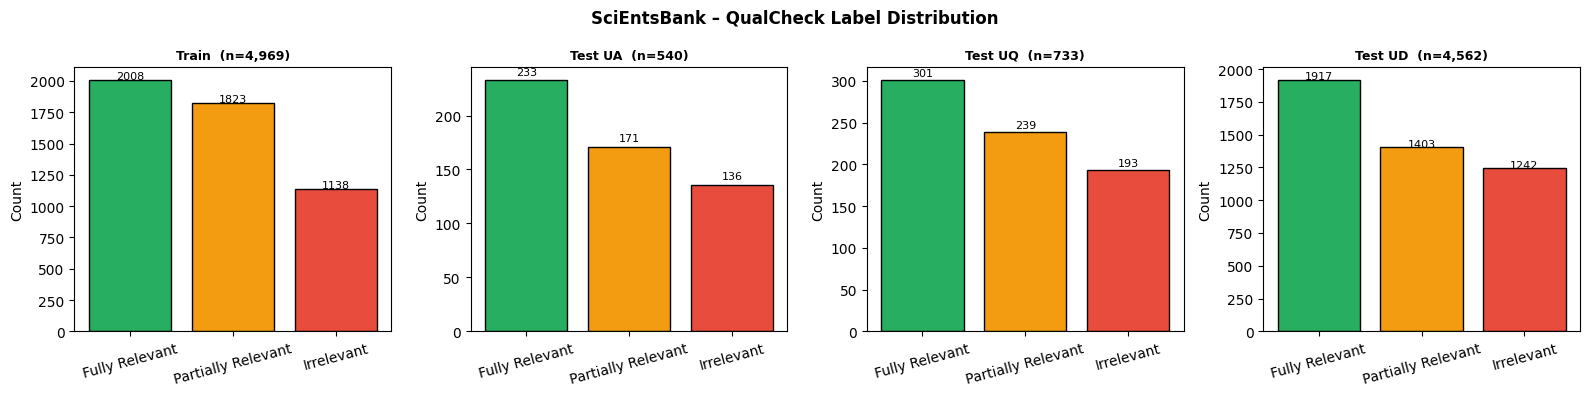

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
split_names = ["Train", "Test UA", "Test UQ", "Test UD"]
dfs         = [train_all_df, test_ua_df, test_uq_df, test_ud_df]
label_order = ["Fully Relevant", "Partially Relevant", "Irrelevant"]
colors      = ["#27ae60", "#f39c12", "#e74c3c"]

for ax, name, df in zip(axes, split_names, dfs):
    counts = [df[df["quality_label"]==l].shape[0] for l in label_order]
    bars   = ax.bar(label_order, counts, color=colors, edgecolor="black")
    ax.set_title(f"{name}  (n={len(df):,})", fontsize=9, fontweight="bold")
    ax.set_ylabel("Count"); ax.tick_params(axis="x", rotation=15)
    for bar, cnt in zip(bars, counts):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
                str(cnt), ha="center", fontsize=8)

plt.suptitle("SciEntsBank – QualCheck Label Distribution", fontweight="bold")
plt.tight_layout()
plt.savefig(f"{cfg.OUTPUT_DIR}/label_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


### Step 3 – Text Preprocessing (NLTK + spaCy)

In [8]:
class TextPreprocessor:
    def __init__(self):
        self.lemmatizer = WordNetLemmatizer()
        self.stop_words = set(stopwords.words("english"))

    def clean_for_bert(self, text):
        return str(text).strip() if not pd.isna(text) else ""

    def deep_clean(self, text):
        if pd.isna(text): return ""
        tokens = nltk.word_tokenize(str(text).lower())
        return " ".join(self.lemmatizer.lemmatize(t)
                         for t in tokens if t.isalnum() and t not in self.stop_words)

prep = TextPreprocessor()

def preprocess_df(df):
    df = df.copy()
    df["clean_question"] = df["question"].apply(prep.clean_for_bert)
    df["clean_response"] = df["response"].apply(prep.clean_for_bert)
    df["tfidf_question"] = df["question"].apply(prep.deep_clean)
    df["tfidf_rubric"]   = df["full_rubric"].apply(prep.deep_clean)
    df["tfidf_response"] = df["response"].apply(prep.deep_clean)
    return df

train_all_df = preprocess_df(train_all_df)
test_ua_df   = preprocess_df(test_ua_df)
test_uq_df   = preprocess_df(test_uq_df)
test_ud_df   = preprocess_df(test_ud_df)

print("✓ Preprocessing complete")
print("\nExample entry:")
print(f"  Q  : {train_all_df['clean_question'].iloc[0]}")
print(f"  R  : {train_all_df['clean_response'].iloc[0]}")
print(f"  Lbl: {train_all_df['quality_label'].iloc[0]}")


✓ Preprocessing complete

Example entry:
  Q  : You used several methods to separate and identify the substances in mock rocks. How did you separate the salt from the water?
  R  : By letting it sit in a dish for a day.
  Lbl: Irrelevant


### Step 4 – Create Validation Set from Training Data

In [9]:
# SciEntsBank already has 3 held-out test sets.
# We carve a validation set out of the training split for threshold calibration.
#
# CHANGED: split by held-out QUESTION (GroupShuffleSplit) instead of a plain
# stratify-by-label split. The old split let the same question appear in both
# train and val -- val was measuring "new answer, seen question" performance,
# which is much closer to test_ua than to test_uq/test_ud. That's why val_wf1
# (~0.64) sat far above test_uq/test_ud (~0.38-0.44): val wasn't testing the
# same kind of generalization the hard test splits require. Grouping by
# question means val now measures genuinely unseen-question performance too,
# so val numbers stop being an optimistic preview and start being honest.
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=cfg.VAL_RATIO, random_state=cfg.SEED)
train_idx, val_idx = next(gss.split(train_all_df, groups=train_all_df["question"]))

train_df = train_all_df.iloc[train_idx].reset_index(drop=True)
val_df   = train_all_df.iloc[val_idx].reset_index(drop=True)

train_qs = set(train_df["question"].unique())
val_qs   = set(val_df["question"].unique())
overlap  = train_qs & val_qs

N = len(train_all_df)
print(f"Train : {len(train_df):>5,}  ({len(train_df)/N*100:.1f}%)  |  {len(train_qs)} unique questions")
print(f"Val   : {len(val_df):>5,}  ({len(val_df)/N*100:.1f}%)  |  {len(val_qs)} unique questions")
print(f"Question overlap between train/val: {len(overlap)}  (must be 0)")
assert len(overlap) == 0, "train/val question leakage -- split is broken"

print(f"\nTest splits kept intact:")
print(f"  test_ua : {len(test_ua_df):,}")
print(f"  test_uq : {len(test_uq_df):,}")
print(f"  test_ud : {len(test_ud_df):,}")
print("\nTrain label distribution:")
print(train_df["quality_label"].value_counts().to_string())
print("\nVal label distribution:")
print(val_df["quality_label"].value_counts().to_string())


Train : 4,149  (83.5%)  |  114 unique questions
Val   :   820  (16.5%)  |  21 unique questions
Question overlap between train/val: 0  (must be 0)

Test splits kept intact:
  test_ua : 540
  test_uq : 733
  test_ud : 4,562

Train label distribution:
quality_label
Fully Relevant        1699
Partially Relevant    1548
Irrelevant             902

Val label distribution:
quality_label
Fully Relevant        309
Partially Relevant    275
Irrelevant            236


## Phase 2 – BERT Encoding & Fine-Tuning

In [10]:
class QualCheckDataset(Dataset):
    """
    P  →  [CLS] question [SEP] rubric_descriptor [SEP]
    R  →  [CLS] student_answer [SEP]
    """
    def __init__(self, df, tokenizer, max_len):
        self.df  = df.reset_index(drop=True)
        self.tok = tokenizer
        self.ml  = max_len

    def __len__(self): return len(self.df)

    def _enc(self, a, b=None):
        return self.tok(a, b,
            add_special_tokens=True, max_length=self.ml,
            padding="max_length", truncation=True,
            return_attention_mask=True, return_tensors="pt")

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        pr  = self._enc(row["clean_question"], row["full_rubric"])
        r   = self._enc(row["clean_response"])
        return {
            "pr_ids"  : pr["input_ids"].squeeze(0),
            "pr_mask" : pr["attention_mask"].squeeze(0),
            "r_ids"   : r["input_ids"].squeeze(0),
            "r_mask"  : r["attention_mask"].squeeze(0),
            "label"   : torch.tensor(row["label_id"], dtype=torch.long)
        }


In [11]:
class QualCheckModel(nn.Module):
    """Siamese BERT with a 4-feature classification head."""
    def __init__(self, bert_name, num_labels=3, dropout=0.3):
        super().__init__()
        self.bert       = BertModel.from_pretrained(bert_name)
        hidden          = self.bert.config.hidden_size
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Sequential(
            nn.Linear(hidden * 4, hidden), nn.Tanh(),
            nn.Dropout(dropout), nn.Linear(hidden, num_labels))

    def encode(self, ids, mask):
        return self.dropout(
            self.bert(input_ids=ids, attention_mask=mask).last_hidden_state[:, 0, :])

    def forward(self, pr_ids, pr_mask, r_ids, r_mask):
        p   = self.encode(pr_ids, pr_mask)
        r   = self.encode(r_ids,  r_mask)
        cos = F.cosine_similarity(p, r, dim=1, eps=1e-8)
        return self.classifier(torch.cat([p, r, torch.abs(p-r), p*r], dim=1)), cos, p, r

    @torch.no_grad()
    def similarity(self, pr_ids, pr_mask, r_ids, r_mask):
        p = self.encode(pr_ids, pr_mask)
        r = self.encode(r_ids,  r_mask)
        return F.cosine_similarity(p, r, dim=1, eps=1e-8)


In [12]:
cel = nn.CrossEntropyLoss()

def train_epoch(model, loader, opt, sch, device):
    model.train()
    tl = correct = n = 0
    for b in tqdm(loader, desc="  Train", leave=False):
        prid=b["pr_ids"].to(device); prm=b["pr_mask"].to(device)
        rid=b["r_ids"].to(device);   rm=b["r_mask"].to(device)
        lbl=b["label"].to(device)
        opt.zero_grad()
        logits,_,_,_ = model(prid,prm,rid,rm)
        loss = cel(logits, lbl); loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step(); sch.step()
        tl += loss.item()*lbl.size(0)
        correct += (logits.argmax(1)==lbl).sum().item()
        n += lbl.size(0)
    return tl/n, correct/n

@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    tl = correct = n = 0; pa=[]; la=[]
    for b in tqdm(loader, desc="  Eval ", leave=False):
        prid=b["pr_ids"].to(device); prm=b["pr_mask"].to(device)
        rid=b["r_ids"].to(device);   rm=b["r_mask"].to(device)
        lbl=b["label"].to(device)
        logits,_,_,_ = model(prid,prm,rid,rm)
        loss = cel(logits, lbl)
        tl += loss.item()*lbl.size(0)
        p = logits.argmax(1)
        correct += (p==lbl).sum().item(); n += lbl.size(0)
        pa.extend(p.cpu().tolist()); la.extend(lbl.cpu().tolist())
    wf1 = f1_score(la, pa, average="weighted", zero_division=0)
    return tl/n, correct/n, wf1

@torch.no_grad()
def get_sims(model, df, tokenizer, cfg):
    ds  = QualCheckDataset(df, tokenizer, cfg.MAX_LEN)
    ld  = DataLoader(ds, batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)
    sims=[]; lbls=[]
    for b in tqdm(ld, desc="  Embed", leave=False):
        cos = model.similarity(
            b["pr_ids"].to(cfg.DEVICE), b["pr_mask"].to(cfg.DEVICE),
            b["r_ids"].to(cfg.DEVICE),  b["r_mask"].to(cfg.DEVICE))
        sims.extend(cos.cpu().tolist()); lbls.extend(b["label"].tolist())
    return np.array(sims), np.array(lbls)


### Run Fine-Tuning

In [13]:
tokenizer = BertTokenizer.from_pretrained(cfg.BERT_MODEL)
model     = QualCheckModel(cfg.BERT_MODEL, cfg.NUM_LABELS, cfg.DROPOUT).to(cfg.DEVICE)

train_loader = DataLoader(QualCheckDataset(train_df, tokenizer, cfg.MAX_LEN),
                          batch_size=cfg.BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(QualCheckDataset(val_df,   tokenizer, cfg.MAX_LEN),
                          batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)

total_steps = len(train_loader) * cfg.MAX_EPOCHS
opt = AdamW(model.parameters(), lr=cfg.LR, eps=1e-8, weight_decay=0.02)  # was 0.01
sch = get_linear_schedule_with_warmup(opt, int(total_steps*cfg.WARMUP_RATIO), total_steps)

# Per Chapter 3 Phase 2: early stopping (and best-checkpoint selection)
# is driven by validation LOSS, not validation Weighted F1 — matches the
# Code Report and Essay notebooks for consistency.
history = {k:[] for k in ["tr_loss","tr_acc","val_loss","val_acc","val_wf1"]}
best_val_loss = float("inf")
best_val_wf1  = 0.0
no_imp = 0

print(f"Training  |  device={cfg.DEVICE}  |  steps={total_steps}"); print("="*60)
for epoch in range(cfg.MAX_EPOCHS):
    trl, tra        = train_epoch(model, train_loader, opt, sch, cfg.DEVICE)
    vl,  va,  vwf1  = evaluate(model,   val_loader,   cfg.DEVICE)
    for k,v in zip(["tr_loss","tr_acc","val_loss","val_acc","val_wf1"],[trl,tra,vl,va,vwf1]):
        history[k].append(v)
    tag = ""
    if vl < best_val_loss:
        best_val_loss = vl; best_val_wf1 = vwf1; tag = "  ← best (lowest val_loss)"; no_imp = 0
        cpu_state = {k: v.detach().cpu().contiguous() for k, v in model.state_dict().items()}
        st_save_file(cpu_state, cfg.BEST_CKPT)
    else:
        no_imp += 1
    print(f"Ep {epoch+1}  tr_loss={trl:.4f}  tr_acc={tra:.4f}  val_loss={vl:.4f}  val_acc={va:.4f}  val_wf1={vwf1:.4f}{tag}")
    if no_imp >= cfg.PATIENCE:
        print(f"Early stopping at epoch {epoch+1} (no val_loss improvement for {cfg.PATIENCE} epochs)"); break

print(f"\nBest Val Loss        : {best_val_loss:.4f}")
print(f"Best Val Weighted-F1 : {best_val_wf1:.4f}  (at best-val-loss checkpoint)")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Training  |  device=cuda  |  steps=1300


  Train:   0%|          | 0/260 [00:00<?, ?it/s]

  Eval :   0%|          | 0/52 [00:00<?, ?it/s]

...

Ep 3  tr_loss=0.6796  tr_acc=0.6994  val_loss=1.4680  val_acc=0.3988  val_wf1=0.3948


  Train:   0%|          | 0/260 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a4d827651c0>
Traceback (most recent call last):
  File "/home/marcdextersael/miniconda3/envs/sabio/lib/python3.11/site-packages/torch/utils/data/dataloader.py", line 1604, in __del__
    self._shutdown_workers()
  File "/home/marcdextersael/miniconda3/envs/sabio/lib/python3.11/site-packages/torch/utils/data/dataloader.py", line 1587, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/home/marcdextersael/miniconda3/envs/sabio/lib/python3.11/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a4d827651c0>
Traceback (most recent call last):
  File "/home/marcdextersael/miniconda3/envs/sabio/lib/python3.11/site-packages/torch/utils/data/dataloader.py", line 

  Eval :   0%|          | 0/52 [00:00<?, ?it/s]

Ep 4  tr_loss=0.4977  tr_acc=0.7980  val_loss=1.6203  val_acc=0.3866  val_wf1=0.3843
Early stopping at epoch 4 (no val_loss improvement for 3 epochs)

Best Val Loss        : 1.1284
Best Val Weighted-F1 : 0.3881  (at best-val-loss checkpoint)


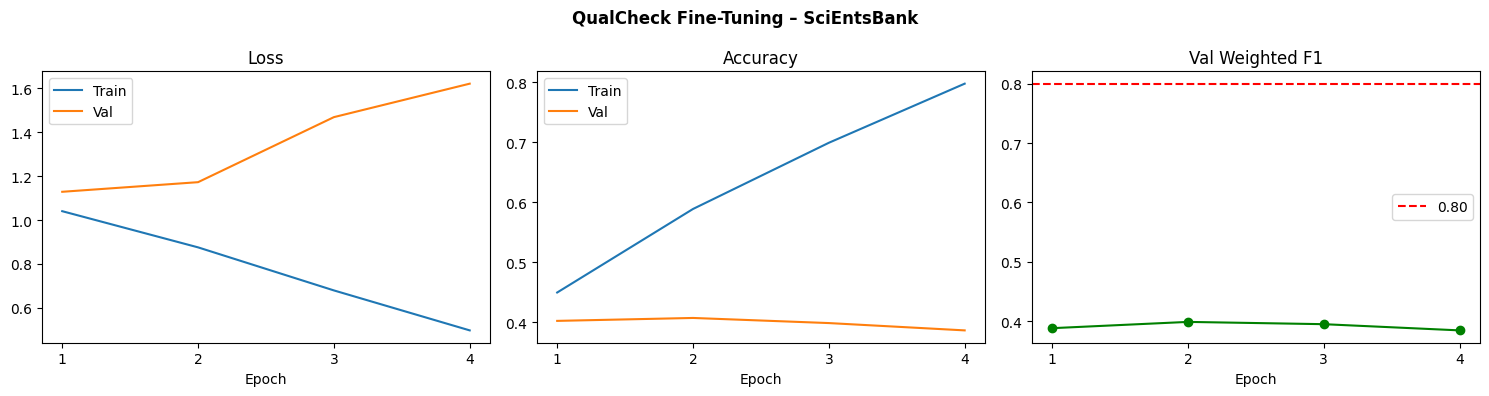

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
ep = range(1, len(history["tr_loss"])+1)
axes[0].plot(ep, history["tr_loss"], label="Train"); axes[0].plot(ep, history["val_loss"], label="Val"); axes[0].set_title("Loss"); axes[0].legend()
axes[1].plot(ep, history["tr_acc"],  label="Train"); axes[1].plot(ep, history["val_acc"],  label="Val"); axes[1].set_title("Accuracy"); axes[1].legend()
axes[2].plot(ep, history["val_wf1"], color="green", marker="o")
axes[2].axhline(0.80, color="red", linestyle="--", label="0.80"); axes[2].set_title("Val Weighted F1"); axes[2].legend()
for ax in axes: ax.set_xlabel("Epoch"); ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.suptitle("QualCheck Fine-Tuning – SciEntsBank", fontweight="bold"); plt.tight_layout()
plt.savefig(f"{cfg.OUTPUT_DIR}/training_history.png", dpi=150, bbox_inches="tight"); plt.show()


## Phase 3 – Cosine Similarity Scoring

In [15]:
state_dict = st_load_file(cfg.BEST_CKPT, device=str(cfg.DEVICE))
model.load_state_dict(state_dict)
model.eval()

print("Extracting cosine similarities …")
val_sims,    val_true    = get_sims(model, val_df,   tokenizer, cfg)
ua_sims,     ua_true     = get_sims(model, test_ua_df, tokenizer, cfg)
uq_sims,     uq_true     = get_sims(model, test_uq_df, tokenizer, cfg)
ud_sims,     ud_true     = get_sims(model, test_ud_df, tokenizer, cfg)

for name, sims in [("Val",val_sims),("Test UA",ua_sims),("Test UQ",uq_sims),("Test UD",ud_sims)]:
    print(f"{name:<10}  min={sims.min():.4f}  max={sims.max():.4f}  mean={sims.mean():.4f}")


Extracting cosine similarities …


  Embed:   0%|          | 0/52 [00:00<?, ?it/s]

  Embed:   0%|          | 0/34 [00:00<?, ?it/s]

  Embed:   0%|          | 0/46 [00:00<?, ?it/s]

  Embed:   0%|          | 0/286 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a4d827651c0>
Traceback (most recent call last):
  File "/home/marcdextersael/miniconda3/envs/sabio/lib/python3.11/site-packages/torch/utils/data/dataloader.py", line 1604, in __del__
    self._shutdown_workers()
  File "/home/marcdextersael/miniconda3/envs/sabio/lib/python3.11/site-packages/torch/utils/data/dataloader.py", line 1587, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/home/marcdextersael/miniconda3/envs/sabio/lib/python3.11/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a4d827651c0><function _MultiProcessingDataLoaderIter.__del__ at 0x7a4d827651c0>

Traceback (most recent call last):
Traceback (most recent call 

Val         min=-0.0673  max=0.7783  mean=0.3233
Test UA     min=-0.0668  max=0.7967  mean=0.3917
Test UQ     min=-0.0352  max=0.7964  mean=0.3897
Test UD     min=-0.1294  max=0.8031  mean=0.3525


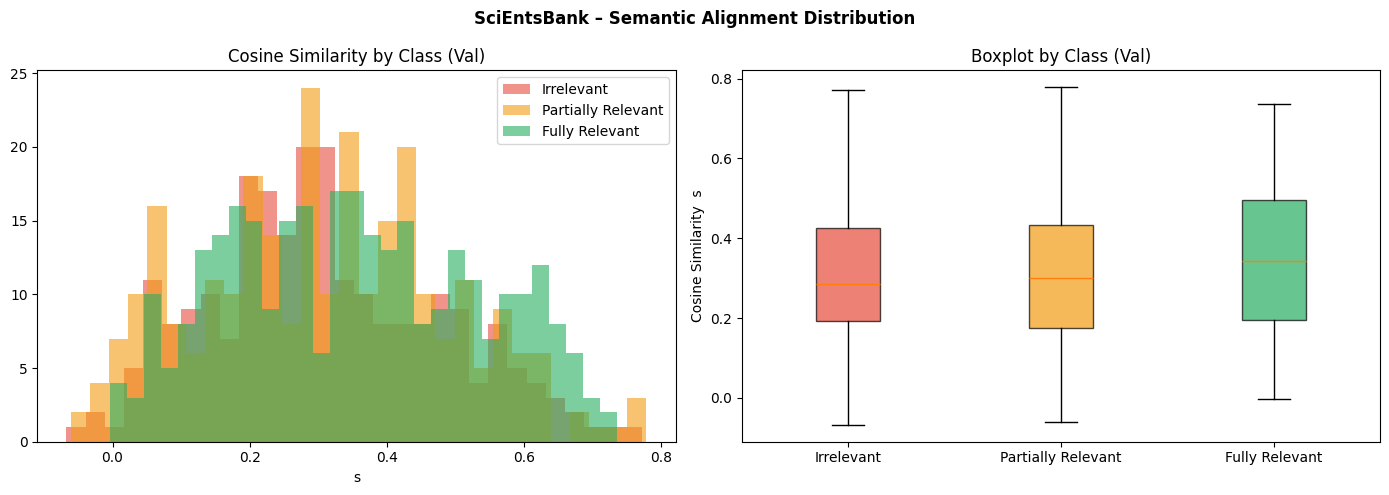

In [16]:
label_names = ["Irrelevant", "Partially Relevant", "Fully Relevant"]
colors_cls  = ["#e74c3c", "#f39c12", "#27ae60"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for lid in range(3):
    m = val_true == lid
    axes[0].hist(val_sims[m], bins=30, alpha=0.6, label=label_names[lid], color=colors_cls[lid])
axes[0].set_title("Cosine Similarity by Class (Val)"); axes[0].set_xlabel("s"); axes[0].legend()

bp = axes[1].boxplot([val_sims[val_true==i] for i in range(3)],
                     labels=label_names, patch_artist=True)
for patch, c in zip(bp["boxes"], colors_cls): patch.set_facecolor(c); patch.set_alpha(0.7)
axes[1].set_title("Boxplot by Class (Val)"); axes[1].set_ylabel("Cosine Similarity  s")
plt.suptitle("SciEntsBank – Semantic Alignment Distribution", fontweight="bold"); plt.tight_layout()
plt.savefig(f"{cfg.OUTPUT_DIR}/similarity_distribution.png", dpi=150, bbox_inches="tight"); plt.show()


## Phase 4 – Threshold Calibration (Grid Search on Val)

In [17]:
def classify(sims, t1, t2):
    p = np.zeros(len(sims), dtype=int)
    p[sims >= t1]                  = 2
    p[(sims >= t2) & (sims < t1)] = 1
    return p

def grid_search(sims, true_labels, step=0.01):
    cands = np.arange(float(sims.min()), float(sims.max()), step)
    best  = dict(t1=0.8, t2=0.5, score=0.0)
    for t1 in cands:
        for t2 in cands:
            if t2 >= t1: continue
            pr  = classify(sims, t1, t2)
            acc = accuracy_score(true_labels, pr)
            wf1 = f1_score(true_labels, pr, average="weighted", zero_division=0)
            s   = (acc + wf1) / 2
            if s > best["score"]:
                best.update(t1=t1, t2=t2, score=s)
    return best

print("Running grid search on validation set …")
res = grid_search(val_sims, val_true, cfg.THRESH_STEP)
θ1  = res["t1"]; θ2 = res["t2"]

print(f"\n{'='*50}")
print(f" θ₁ (Fully Relevant   boundary) : {θ1:.4f}")
print(f" θ₂ (Irrelevant       boundary) : {θ2:.4f}")
print(f" Combined score                 : {res['score']:.4f}")
print(f"\n s ≥ {θ1:.4f}               → Fully Relevant")
print(f" {θ2:.4f} ≤ s < {θ1:.4f}  → Partially Relevant")
print(f" s <  {θ2:.4f}               → Irrelevant")


Running grid search on validation set …

 θ₁ (Fully Relevant   boundary) : 0.4527
 θ₂ (Irrelevant       boundary) : 0.3227
 Combined score                 : 0.3783

 s ≥ 0.4527               → Fully Relevant
 0.3227 ≤ s < 0.4527  → Partially Relevant
 s <  0.3227               → Irrelevant


## Phase 5 – Evaluation on All Three Test Splits

SciEntsBank has three distinct generalisation challenges:
- **test_ua** – same questions, same domains, new student answers
- **test_uq** – same domains, new questions (never seen at training)
- **test_ud** – entirely new science domains (hardest)

In [18]:
def evaluate_split(sims, true_labels, θ1, θ2, split_name):
    preds = classify(sims, θ1, θ2)
    acc   = accuracy_score(true_labels, preds)
    prec  = precision_score(true_labels, preds, average="weighted", zero_division=0)
    rec   = recall_score(true_labels, preds,    average="weighted", zero_division=0)
    f1m   = f1_score(true_labels, preds, average="macro",    zero_division=0)
    f1w   = f1_score(true_labels, preds, average="weighted", zero_division=0)
    norm  = true_labels / (cfg.NUM_LABELS - 1)
    mae   = np.mean(np.abs(sims - norm))
    rmse  = np.sqrt(np.mean((sims - norm)**2))
    r, pr = pearsonr(sims, norm) if len(sims) > 2 else (float("nan"), float("nan"))

    print(f"\n{'='*55}")
    print(f" {split_name}  (n={len(true_labels):,})")
    print(f"{'='*55}")
    print(f" Accuracy       : {acc:.4f}")
    print(f" Precision (W)  : {prec:.4f}")
    print(f" Recall    (W)  : {rec:.4f}")
    print(f" F1 (macro)     : {f1m:.4f}")
    print(f" Weighted F1    : {f1w:.4f}  ({'✓' if f1w>=0.80 else '✗'} ≥ 0.80)")
    print(f" MAE            : {mae:.4f}")
    print(f" RMSE           : {rmse:.4f}")
    print(f" Pearson r      : {r:.4f}  ({'✓' if r>=0.70 else '✗'} ≥ 0.70)")
    print(f"\nClassification Report:")
    print(classification_report(true_labels, preds, target_names=label_names))
    return dict(split=split_name, n=len(true_labels),
                acc=acc, prec=prec, rec=rec, f1_macro=f1m,
                weighted_f1=f1w, mae=mae, rmse=rmse, pearson_r=r), preds

results_ua, preds_ua = evaluate_split(ua_sims, ua_true, θ1, θ2, "Test UA – Unseen Answers")
results_uq, preds_uq = evaluate_split(uq_sims, uq_true, θ1, θ2, "Test UQ – Unseen Questions")
results_ud, preds_ud = evaluate_split(ud_sims, ud_true, θ1, θ2, "Test UD – Unseen Domains")



 Test UA – Unseen Answers  (n=540)
 Accuracy       : 0.4241
 Precision (W)  : 0.4271
 Recall    (W)  : 0.4241
 F1 (macro)     : 0.4105
 Weighted F1    : 0.4203  (✗ ≥ 0.80)
 MAE            : 0.3829
 RMSE           : 0.4510
 Pearson r      : 0.2329  (✗ ≥ 0.70)

Classification Report:
                    precision    recall  f1-score   support

        Irrelevant       0.36      0.51      0.43       136
Partially Relevant       0.35      0.26      0.30       171
    Fully Relevant       0.52      0.49      0.51       233

          accuracy                           0.42       540
         macro avg       0.41      0.42      0.41       540
      weighted avg       0.43      0.42      0.42       540


 Test UQ – Unseen Questions  (n=733)
 Accuracy       : 0.3520
 Precision (W)  : 0.3509
 Recall    (W)  : 0.3520
 F1 (macro)     : 0.3368
 Weighted F1    : 0.3456  (✗ ≥ 0.80)
 MAE            : 0.3951
 RMSE           : 0.4601
 Pearson r      : 0.1420  (✗ ≥ 0.70)

Classification Report:
       

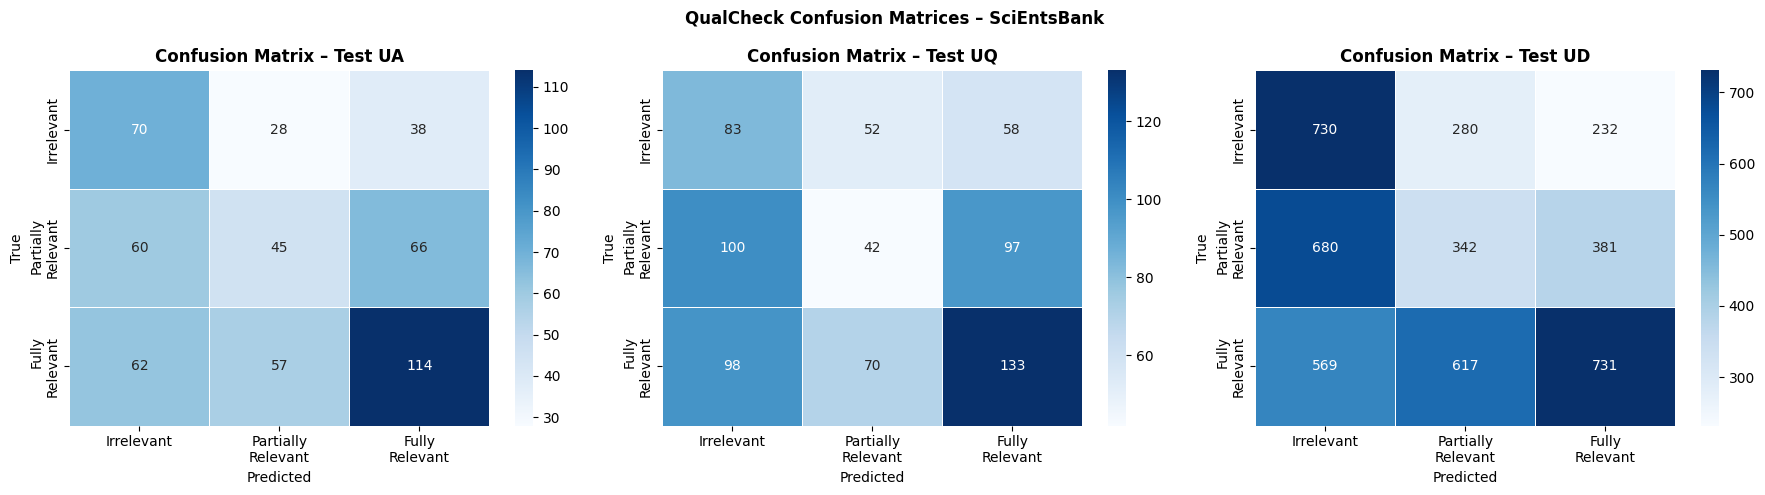

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cls_names = ["Irrelevant", "Partially\nRelevant", "Fully\nRelevant"]

for ax, (name, true, pred) in zip(axes, [
        ("Test UA", ua_true, preds_ua),
        ("Test UQ", uq_true, preds_uq),
        ("Test UD", ud_true, preds_ud)]):
    cm = confusion_matrix(true, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=cls_names, yticklabels=cls_names,
                linewidths=0.5, ax=ax)
    ax.set_title(f"Confusion Matrix – {name}", fontweight="bold")
    ax.set_ylabel("True"); ax.set_xlabel("Predicted")

plt.suptitle("QualCheck Confusion Matrices – SciEntsBank", fontweight="bold")
plt.tight_layout()
plt.savefig(f"{cfg.OUTPUT_DIR}/confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()


### Cross-Split Performance Summary

Cross-Split Summary
                     split    n      acc  weighted_f1  f1_macro  pearson_r      mae
  Test UA – Unseen Answers  540 0.424074     0.420315  0.410459   0.232910 0.382879
Test UQ – Unseen Questions  733 0.351978     0.345624  0.336754   0.142018 0.395131
  Test UD – Unseen Domains 4562 0.395221     0.391417  0.386833   0.245170 0.393827


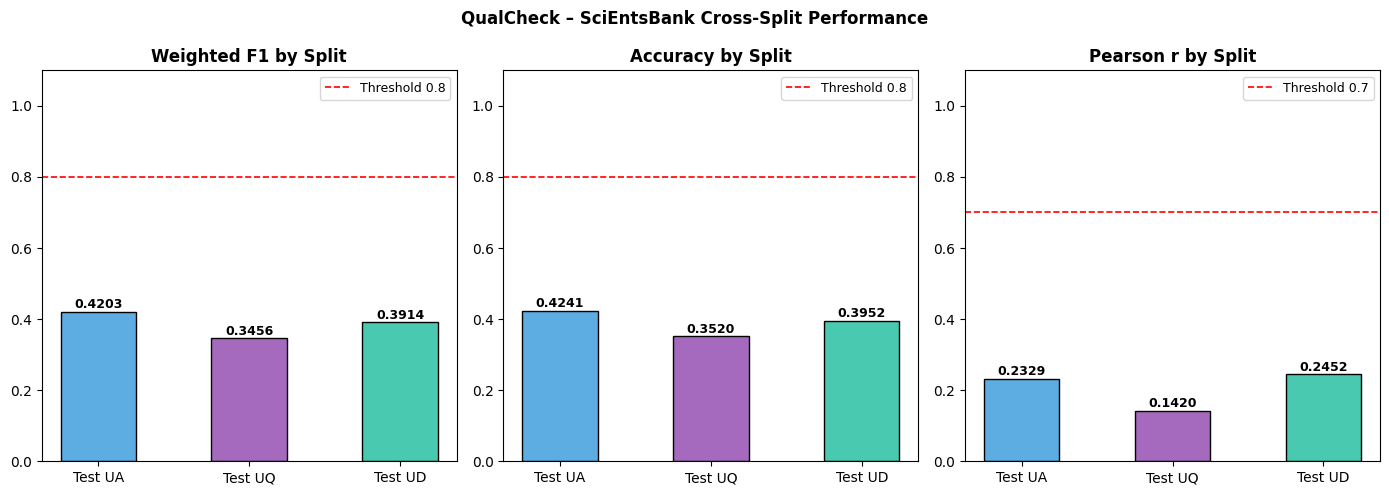

In [20]:
summary_df = pd.DataFrame([results_ua, results_uq, results_ud])
summary_df.to_csv(f"{cfg.OUTPUT_DIR}/split_results_summary.csv", index=False)

print("Cross-Split Summary")
print(summary_df[["split","n","acc","weighted_f1","f1_macro","pearson_r","mae"]].to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics  = ["weighted_f1", "acc", "pearson_r"]
mtitles  = ["Weighted F1",  "Accuracy", "Pearson r"]
split_l  = ["Test UA", "Test UQ", "Test UD"]
bar_cols = ["#5dade2", "#a569bd", "#48c9b0"]
thresholds = [0.80, 0.80, 0.70]

for ax, met, title, thr in zip(axes, metrics, mtitles, thresholds):
    vals = summary_df[met].tolist()
    bars = ax.bar(split_l, vals, color=bar_cols, edgecolor="black", width=0.5)
    ax.set_ylim(0, 1.1); ax.axhline(thr, color="red", linestyle="--", lw=1.2, label=f"Threshold {thr}")
    ax.set_title(f"{title} by Split", fontweight="bold"); ax.legend(fontsize=9)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f"{v:.4f}",
                ha="center", fontweight="bold", fontsize=9)

plt.suptitle("QualCheck – SciEntsBank Cross-Split Performance", fontweight="bold")
plt.tight_layout()
plt.savefig(f"{cfg.OUTPUT_DIR}/cross_split_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


### Baseline Comparisons (Test UA)

--- Baseline 1: TF-IDF Cosine Similarity ---
  Acc=0.3741  WF1=0.3774  r=0.0936  MAE=0.4954

--- Baseline 2: BERT without rubric (question only) ---


  BL2:   0%|          | 0/820 [00:00<?, ?it/s]

  BL2:   0%|          | 0/540 [00:00<?, ?it/s]

  Acc=0.4241  WF1=0.3814  r=0.1700  MAE=0.3685

Baseline Comparison (Test UA):
                System  Accuracy  Weighted F1  Pearson r      MAE  ΔWF1 vs BL1
          BL1 – TF-IDF  0.374074     0.377443   0.093598 0.495395       0.0000
BL2 – BERT (no rubric)  0.424074     0.381396   0.169984 0.368528       0.0040
      QualCheck (Ours)  0.424074     0.420315   0.232910 0.382879       0.0429


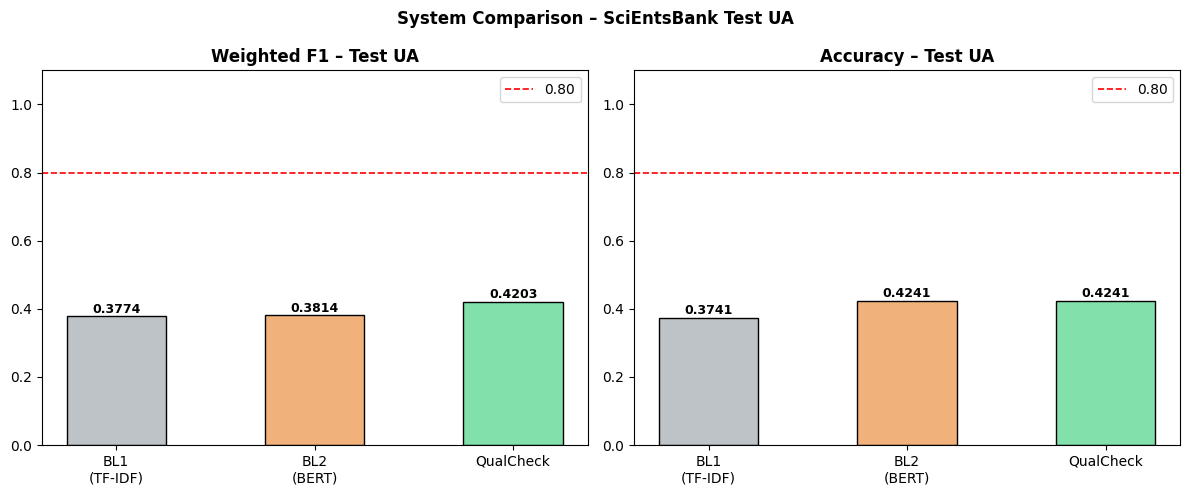

In [21]:
# Use test_ua as the primary comparison split
print("--- Baseline 1: TF-IDF Cosine Similarity ---")
all_tfidf = (list(train_df["tfidf_question"] + " " + train_df["tfidf_rubric"]) +
             list(train_df["tfidf_response"]))
tv = TfidfVectorizer(max_features=10_000, ngram_range=(1,2)); tv.fit(all_tfidf)

def tfidf_sims(df_sp):
    pr = tv.transform(df_sp["tfidf_question"] + " " + df_sp["tfidf_rubric"])
    r  = tv.transform(df_sp["tfidf_response"])
    return np.array([tfidf_cos(pr[i], r[i])[0,0] for i in range(len(df_sp))])

bl1_val = tfidf_sims(val_df);    bl1_ua  = tfidf_sims(test_ua_df)
bl1_res = grid_search(bl1_val, val_true, 0.01)
bl1_p   = classify(bl1_ua, bl1_res["t1"], bl1_res["t2"])
bl1_wf1 = f1_score(ua_true, bl1_p, average="weighted", zero_division=0)
bl1_acc = accuracy_score(ua_true, bl1_p)
bl1_r,_ = pearsonr(bl1_ua, ua_true/(cfg.NUM_LABELS-1))
bl1_mae = np.mean(np.abs(bl1_ua - ua_true/(cfg.NUM_LABELS-1)))
print(f"  Acc={bl1_acc:.4f}  WF1={bl1_wf1:.4f}  r={bl1_r:.4f}  MAE={bl1_mae:.4f}")

print("\n--- Baseline 2: BERT without rubric (question only) ---")
@torch.no_grad()
def bert_no_rubric(model, df_sp, tokenizer, cfg):
    sims = []
    model.eval()
    for _, row in tqdm(df_sp.iterrows(), total=len(df_sp), desc="  BL2", leave=False):
        q = tokenizer(row["clean_question"],
              add_special_tokens=True, max_length=cfg.MAX_LEN,
              padding="max_length", truncation=True,
              return_attention_mask=True, return_tensors="pt")
        r = tokenizer(row["clean_response"],
              add_special_tokens=True, max_length=cfg.MAX_LEN,
              padding="max_length", truncation=True,
              return_attention_mask=True, return_tensors="pt")
        sims.append(model.similarity(
            q["input_ids"].to(cfg.DEVICE), q["attention_mask"].to(cfg.DEVICE),
            r["input_ids"].to(cfg.DEVICE), r["attention_mask"].to(cfg.DEVICE)).item())
    return np.array(sims)

bl2_val = bert_no_rubric(model, val_df,     tokenizer, cfg)
bl2_ua  = bert_no_rubric(model, test_ua_df, tokenizer, cfg)
bl2_res = grid_search(bl2_val, val_true, 0.01)
bl2_p   = classify(bl2_ua, bl2_res["t1"], bl2_res["t2"])
bl2_wf1 = f1_score(ua_true, bl2_p, average="weighted", zero_division=0)
bl2_acc = accuracy_score(ua_true, bl2_p)
bl2_r,_ = pearsonr(bl2_ua, ua_true/(cfg.NUM_LABELS-1))
bl2_mae = np.mean(np.abs(bl2_ua - ua_true/(cfg.NUM_LABELS-1)))
print(f"  Acc={bl2_acc:.4f}  WF1={bl2_wf1:.4f}  r={bl2_r:.4f}  MAE={bl2_mae:.4f}")

qc_ua_wf1 = results_ua["weighted_f1"]; qc_ua_acc = results_ua["acc"]
qc_ua_r   = results_ua["pearson_r"];   qc_ua_mae = results_ua["mae"]

comp = pd.DataFrame({
    "System"      : ["BL1 – TF-IDF", "BL2 – BERT (no rubric)", "QualCheck (Ours)"],
    "Accuracy"    : [bl1_acc,  bl2_acc,  qc_ua_acc],
    "Weighted F1" : [bl1_wf1,  bl2_wf1,  qc_ua_wf1],
    "Pearson r"   : [bl1_r,    bl2_r,    qc_ua_r],
    "MAE"         : [bl1_mae,  bl2_mae,  qc_ua_mae],
    "ΔWF1 vs BL1" : [0.0, round(bl2_wf1-bl1_wf1,4), round(qc_ua_wf1-bl1_wf1,4)],
})
comp.to_csv(f"{cfg.OUTPUT_DIR}/baseline_comparison.csv", index=False)
print("\nBaseline Comparison (Test UA):")
print(comp.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sl = ["BL1\n(TF-IDF)", "BL2\n(BERT)", "QualCheck"]
bc = ["#bdc3c7", "#f0b27a", "#82e0aa"]
for ax, met in zip(axes, ["Weighted F1", "Accuracy"]):
    vals = comp[met].tolist()
    bars = ax.bar(sl, vals, color=bc, edgecolor="black", width=0.5)
    ax.set_ylim(0, 1.1); ax.axhline(0.80, color="red", linestyle="--", lw=1.2, label="0.80")
    ax.set_title(f"{met} – Test UA", fontweight="bold"); ax.legend()
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f"{v:.4f}",
                ha="center", fontweight="bold", fontsize=9)
plt.suptitle("System Comparison – SciEntsBank Test UA", fontweight="bold"); plt.tight_layout()
plt.savefig(f"{cfg.OUTPUT_DIR}/baseline_comparison.png", dpi=150, bbox_inches="tight"); plt.show()


### Statistical Tests

In [22]:
# 1. Pearson r per split
print("1. Score-Level Agreement (Pearson r)")
for name, sims, true in [("Test UA", ua_sims, ua_true),
                          ("Test UQ", uq_sims, uq_true),
                          ("Test UD", ud_sims, ud_true)]:
    r, p = pearsonr(sims, true/(cfg.NUM_LABELS-1))
    print(f"   {name}: r={r:.4f}  p={p:.4f}  {'✓' if r>=0.70 else '✗'}")

# 2. One-way ANOVA across splits
print("\n2. One-Way ANOVA – consistency across test splits")
f_stat, pv = f_oneway(ua_sims, uq_sims, ud_sims)  # renamed from F -- was shadowing torch.nn.functional as F
print(f"   F={f_stat:.4f}  p={pv:.4f}")
if pv > 0.05:
    print("   Non-significant (p>0.05): consistent across splits ✓")
else:
    print("   Significant (p≤0.05): Tukey HSD:")
    all_s = np.concatenate([ua_sims, uq_sims, ud_sims])
    all_g = ["UA"]*len(ua_sims) + ["UQ"]*len(uq_sims) + ["UD"]*len(ud_sims)
    print(pairwise_tukeyhsd(all_s, all_g, alpha=0.05))

# 3. Descriptive stats (using test_ua as reference)
print("\n3. Descriptive Statistics – Test UA (cosine similarity by class)")
print(f"{'Class':<22} {'Mean':>6} {'Median':>8} {'Std':>6} {'IQR':>6}")
print("-"*50)
for lid, lname in cfg.ID2LABEL.items():
    m = ua_true == lid
    if m.any():
        s = ua_sims[m]
        iqr = np.percentile(s,75)-np.percentile(s,25)
        print(f"{lname:<22} {s.mean():>6.4f} {np.median(s):>8.4f} {s.std():>6.4f} {iqr:>6.4f}")


1. Score-Level Agreement (Pearson r)
   Test UA: r=0.2329  p=0.0000  ✗
   Test UQ: r=0.1420  p=0.0001  ✗
   Test UD: r=0.2452  p=0.0000  ✗

2. One-Way ANOVA – consistency across test splits
   F=24.4595  p=0.0000
   Significant (p≤0.05): Tukey HSD:
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
    UA     UD  -0.0392    0.0 -0.0575 -0.0209   True
    UA     UQ   -0.002 0.9773 -0.0248  0.0208  False
    UD     UQ   0.0372    0.0  0.0212  0.0532   True
----------------------------------------------------

3. Descriptive Statistics – Test UA (cosine similarity by class)
Class                    Mean   Median    Std    IQR
--------------------------------------------------
Fully Relevant         0.4357   0.4495 0.1785 0.2554
Partially Relevant     0.3877   0.3928 0.1963 0.2890
Irrelevant             0.3215   0.3017 0.1990 0.3216


## Save Final Model & Predictions

In [23]:
# Weights → safetensors (tensors only)
final_state = {k: v.detach().cpu().contiguous() for k, v in model.state_dict().items()}
st_save_file(final_state, cfg.FINAL_MODEL_WEIGHTS)

# Everything else → companion JSON (safetensors can't hold non-tensor data)
final_meta = {
    "theta1"                 : float(θ1),
    "theta2"                 : float(θ2),
    "bert_model"             : cfg.BERT_MODEL,
    "max_len"                : cfg.MAX_LEN,
    "label_map"              : cfg.LABEL2ID,
    "seb_to_qc"              : cfg.SEB_TO_QC,
    "accuracy_templates"     : ACCURACY_TEMPLATES,
    "key_concept_templates"  : KEY_CONCEPT_TEMPLATES,
    "clarity_templates"      : CLARITY_TEMPLATES,
    "weights_file"           : cfg.FINAL_MODEL_WEIGHTS,
}
with open(cfg.FINAL_MODEL_META, "w") as f:
    _json.dump(final_meta, f, indent=2)

print(f"Saved weights → {cfg.FINAL_MODEL_WEIGHTS}")
print(f"Saved metadata → {cfg.FINAL_MODEL_META}")

# Save predictions for each test split
for name, df_sp, sims, true, preds in [
        ("test_ua", test_ua_df, ua_sims, ua_true, preds_ua),
        ("test_uq", test_uq_df, uq_sims, uq_true, preds_uq),
        ("test_ud", test_ud_df, ud_sims, ud_true, preds_ud)]:
    out = df_sp[["question","rubric_descriptor","response","quality_label"]].copy()
    out["cosine_similarity"] = sims
    out["predicted_label"]   = [cfg.ID2LABEL[p] for p in preds]
    out["correct"]           = (true == preds)
    out.to_csv(f"{cfg.OUTPUT_DIR}/predictions_{name}.csv", index=False)

print("="*60)
print(" QUALCHECK – SCIENTSBANK FINAL RESULTS")
print("="*60)
print(f" θ₁ = {θ1:.4f}   θ₂ = {θ2:.4f}")
print(f" {'Split':<12} {'WF1':>6} {'Acc':>6} {'r':>6} {'MAE':>6}")
print(" "+"-"*35)
for r in [results_ua, results_uq, results_ud]:
    vf = r["weighted_f1"]; va = r["acc"]; vr = r["pearson_r"]; vm = r["mae"]
    ok = "✓" if vf>=0.80 else "✗"
    print(f" {r['split'].split('–')[0].strip():<12} {vf:>6.4f}{ok} {va:>6.4f} {vr:>6.4f} {vm:>6.4f}")
print("="*60)
print("✓ QualCheck – SciEntsBank pipeline complete!")


Saved weights → qualcheck_short_answers/qualcheck_short_answers_final.safetensors
Saved metadata → qualcheck_short_answers/qualcheck_short_answers_final_meta.json
 QUALCHECK – SCIENTSBANK FINAL RESULTS
 θ₁ = 0.4527   θ₂ = 0.3227
 Split           WF1    Acc      r    MAE
 -----------------------------------
 Test UA      0.4203✗ 0.4241 0.2329 0.3829
 Test UQ      0.3456✗ 0.3520 0.1420 0.3951
 Test UD      0.3914✗ 0.3952 0.2452 0.3938
✓ QualCheck – SciEntsBank pipeline complete!


In [24]:
import os, time, hashlib

print("BATCH_SIZE:", cfg.BATCH_SIZE, "| DROPOUT:", cfg.DROPOUT)
print("BEST_CKPT path:", cfg.BEST_CKPT)
print("BEST_CKPT last modified:", time.ctime(os.path.getmtime(cfg.BEST_CKPT)))
print("Right now:               ", time.ctime())

state = model.state_dict()
first_key = next(iter(state))
print("First param name:", first_key)
print("First param hash:", hashlib.md5(state[first_key].detach().cpu().numpy().tobytes()).hexdigest())

BATCH_SIZE: 16 | DROPOUT: 0.4
BEST_CKPT path: qualcheck_short_answers/best_model.safetensors
BEST_CKPT last modified: Thu Aug  6 07:06:19 2026
Right now:                Thu Aug  6 07:11:06 2026
First param name: bert.embeddings.word_embeddings.weight
First param hash: 74a6861411149a803cb426869856ab46


In [25]:
import os, time
import numpy as np
from sklearn.metrics import accuracy_score, f1_score
from scipy.stats import pearsonr

print("="*70)
print("QUALCHECK FULL SNAPSHOT")
print("="*70)

# ---- Config fingerprint ----
if 'cfg' in globals():
    print(f"BATCH_SIZE={cfg.BATCH_SIZE}  DROPOUT={cfg.DROPOUT}  LR={cfg.LR}  "
          f"MAX_EPOCHS={cfg.MAX_EPOCHS}  PATIENCE={cfg.PATIENCE}  SEED={cfg.SEED}")
    if os.path.isfile(cfg.BEST_CKPT):
        print(f"Checkpoint modified: {time.ctime(os.path.getmtime(cfg.BEST_CKPT))}  "
              f"(now: {time.ctime()})")
else:
    print("cfg not defined yet")
print()

# ---- Training history ----
print("--- Training history ---")
if 'history' in globals() and history.get("tr_loss"):
    for i in range(len(history["tr_loss"])):
        print(f"Ep {i+1}  tr_loss={history['tr_loss'][i]:.4f}  tr_acc={history['tr_acc'][i]:.4f}  "
              f"val_loss={history['val_loss'][i]:.4f}  val_acc={history['val_acc'][i]:.4f}  "
              f"val_wf1={history['val_wf1'][i]:.4f}")
    if 'best_val_loss' in globals():
        print(f"\nBest val_loss: {best_val_loss:.4f}  (val_wf1 at that epoch: {best_val_wf1:.4f})")
else:
    print("not trained yet this session")
print()

# ---- Thresholds ----
_t1 = globals().get('θ1', globals().get('theta1'))
_t2 = globals().get('θ2', globals().get('theta2'))
print(f"--- Thresholds ---\nθ1={_t1}  θ2={_t2}")
print()

# ---- Test results (recomputed directly from sims/true + classify()) ----
print("--- Test results ---")
splits = [("Test UA", 'ua_sims', 'ua_true'), ("Test UQ", 'uq_sims', 'uq_true'), ("Test UD", 'ud_sims', 'ud_true')]
if _t1 is not None and 'classify' in globals():
    for name, sims_key, true_key in splits:
        if sims_key in globals() and true_key in globals():
            sims, true = globals()[sims_key], globals()[true_key]
            pred = classify(sims, _t1, _t2)
            acc  = accuracy_score(true, pred)
            wf1  = f1_score(true, pred, average="weighted")
            r, _ = pearsonr(sims, true / (cfg.NUM_LABELS - 1))
            print(f"{name:<10} n={len(true):<6} Acc={acc:.4f}  WF1={wf1:.4f}  r={r:.4f}")
        else:
            print(f"{name:<10} not available yet")
else:
    print("thresholds or classify() not available yet")

print("="*70)

QUALCHECK FULL SNAPSHOT
BATCH_SIZE=16  DROPOUT=0.4  LR=2e-05  MAX_EPOCHS=5  PATIENCE=3  SEED=42
Checkpoint modified: Thu Aug  6 07:06:19 2026  (now: Thu Aug  6 07:11:07 2026)

--- Training history ---
Ep 1  tr_loss=1.0401  tr_acc=0.4497  val_loss=1.1284  val_acc=0.4024  val_wf1=0.3881
Ep 2  tr_loss=0.8755  tr_acc=0.5891  val_loss=1.1721  val_acc=0.4073  val_wf1=0.3986
Ep 3  tr_loss=0.6796  tr_acc=0.6994  val_loss=1.4680  val_acc=0.3988  val_wf1=0.3948
Ep 4  tr_loss=0.4977  tr_acc=0.7980  val_loss=1.6203  val_acc=0.3866  val_wf1=0.3843

Best val_loss: 1.1284  (val_wf1 at that epoch: 0.3881)

--- Thresholds ---
θ1=0.4527311068773271  θ2=0.32273110687732703

--- Test results ---
Test UA    n=540    Acc=0.4241  WF1=0.4203  r=0.2329
Test UQ    n=733    Acc=0.3520  WF1=0.3456  r=0.1420
Test UD    n=4562   Acc=0.3952  WF1=0.3914  r=0.2452
